Dataset Preview:
       Year               Country Energy Product Name   Flow Breakdown  \
0  1/1/2002  United Arab Emirates           Crude Oil  Refinery intake   
1  2/1/2002  United Arab Emirates           Crude Oil  Refinery intake   
2  2/1/2002  United Arab Emirates           Crude Oil  Refinery intake   
3  2/1/2002  United Arab Emirates           Crude Oil  Refinery intake   
4  2/1/2002  United Arab Emirates           Crude Oil          Exports   

  Unit Of Measure       Value  Assessment Code  
0             KBD   202.00000                3  
1         CONVBBL  7596.00000                3  
2            KBBL  6104.00000                3  
3           KTONS   803.58081                3  
4         CONVBBL  7596.00000                3  

Columns:
Index(['Year', 'Country', 'Energy Product Name', 'Flow Breakdown',
       'Unit Of Measure', 'Value', 'Assessment Code'],
      dtype='str')

Edges Preview:
    source                                      target        weight
0  Alger

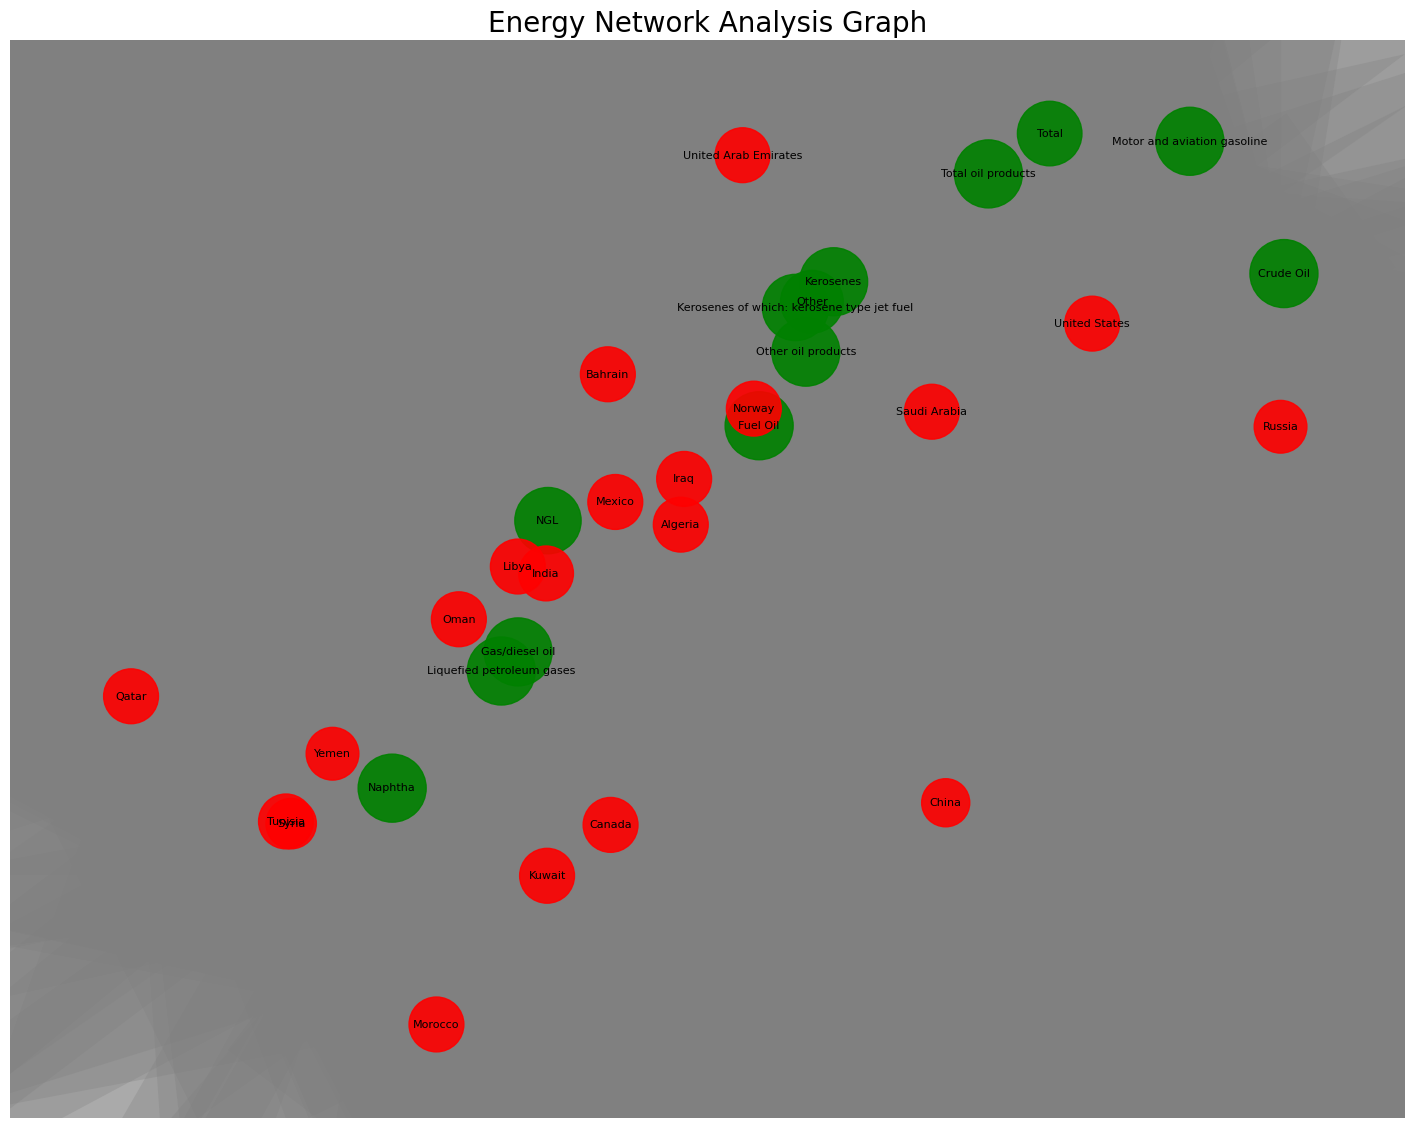


FORMULAS:

Degree Centrality:
CD(v) = deg(v) / (n - 1)

Closeness Centrality:
CC(v) = (n - 1) / Σ d(v,u)

Betweenness Centrality:
CB(v) = Σ (σst(v) / σst)


INTERPRETATION:

1. Degree Centrality:
Measures the number of direct connections
of a node with other nodes.

2. Closeness Centrality:
Measures how close a node is to all
other nodes in the network.

3. Betweenness Centrality:
Measures how often a node appears
on the shortest paths between other nodes.



In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ============================================
# C.1 – IMPORTIMI I DATASET-IT
# ============================================

# Leximi i dataset-it CSV
df = pd.read_csv("world-oil-data-cleaned.csv")

print("Dataset Preview:")
print(df.head())

print("\nColumns:")
print(df.columns)

# ============================================
# CLEAN DATA
# ============================================

# Hiqi vlerat null
df = df.dropna()

# Largo spaces të fshehta
df["Country"] = df["Country"].astype(str).str.strip()
df["Energy Product Name"] = df["Energy Product Name"].astype(str).str.strip()

# Konverto Value në numerik
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Hiqi rows me null pas konvertimit
df = df.dropna()

# Hiqi weight = 0
df = df[df["Value"] > 0]

# ============================================
# C.2 – KRIJIMI I EDGES
# ============================================

# Group by Country -> Product
edges = df.groupby(
    ["Country", "Energy Product Name"]
)["Value"].sum().reset_index()

# Rename columns
edges.columns = ["source", "target", "weight"]

print("\nEdges Preview:")
print(edges.head())

# ============================================
# KRIJIMI I GRAFIT
# ============================================

G = nx.Graph()

# Add edges
for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"]
    )

print("\nGraph Information:")
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

# ============================================
# NODE TYPES
# ============================================

countries = set(df["Country"])

node_types = {}

for node in G.nodes():
    if node in countries:
        node_types[node] = "Country"
    else:
        node_types[node] = "Product"

# ============================================
# C.3 – CENTRALITY METRICS
# ============================================

# Degree Centrality
degree_centrality = nx.degree_centrality(G)

# Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)

# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)

# ============================================
# KRIJIMI I TABELËS ME METRIKA
# ============================================

metrics_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [
        degree_centrality[n]
        for n in G.nodes()
    ],
    "closeness_centrality": [
        closeness_centrality[n]
        for n in G.nodes()
    ],
    "betweenness_centrality": [
        betweenness_centrality[n]
        for n in G.nodes()
    ]
})

print("\nMetrics Preview:")
print(metrics_df.head())

# ============================================
# TOP 10 NYJET MË TË RËNDËSISHME
# ============================================

print("\nTop 10 Nodes by Degree Centrality:")
print(
    metrics_df.sort_values(
        by="degree_centrality",
        ascending=False
    ).head(10)
)

# ============================================
# EXPORT CSV
# ============================================

metrics_df.to_csv(
    "network_metrics.csv",
    index=False
)

print("\nMetrics exported successfully!")

# ============================================
# C.2 – VIZUALIZIMI I GRAFIT
# ============================================

plt.figure(figsize=(18, 14))

# Layout për graf më clean
pos = nx.spring_layout(
    G,
    k=0.7,
    seed=42
)

# Node colors
color_map = [
    "red" if node_types[n] == "Country"
    else "green"
    for n in G.nodes()
]

# Node sizes sipas degree
degrees = dict(G.degree())

node_sizes = [
    v * 120
    for v in degrees.values()
]

# Edge widths sipas weight
weights = [
    G[u][v]["weight"] / 5000
    for u, v in G.edges()
]

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=color_map,
    node_size=node_sizes,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    edge_color="gray",
    alpha=0.3
)

# Labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

# Title
plt.title(
    "Energy Network Analysis Graph",
    fontsize=20
)

# Hide axis
plt.axis("off")

# Show graph
plt.show()

# ============================================
# FORMULAT MATEMATIKORE (PËR RAPORT)
# ============================================

print("\nFORMULAS:")

print("""
Degree Centrality:
CD(v) = deg(v) / (n - 1)

Closeness Centrality:
CC(v) = (n - 1) / Σ d(v,u)

Betweenness Centrality:
CB(v) = Σ (σst(v) / σst)
""")

# ============================================
# INTERPRETIMI I METRIKAVE
# ============================================

print("\nINTERPRETATION:")

print("""
1. Degree Centrality:
Measures the number of direct connections
of a node with other nodes.

2. Closeness Centrality:
Measures how close a node is to all
other nodes in the network.

3. Betweenness Centrality:
Measures how often a node appears
on the shortest paths between other nodes.
""")

In [6]:
# ============================================
# EXPORT NODES CSV
# ============================================

nodes_df = pd.DataFrame({
    "id": list(G.nodes()),
    "label": list(G.nodes()),
    "type": [
        node_types[n]
        for n in G.nodes()
    ]
})

nodes_df.to_csv(
    "nodes.csv",
    index=False
)

print("nodes.csv exported successfully!")

# ============================================
# EXPORT EDGES CSV
# ============================================

edges_export = pd.DataFrame({
    "source": edges["source"],
    "target": edges["target"],
    "weight": edges["weight"]
})

edges_export.to_csv(
    "edges.csv",
    index=False
)

print("edges.csv exported successfully!")

nodes.csv exported successfully!
edges.csv exported successfully!
